In [1]:
%matplotlib inline
from __future__ import division
import matplotlib
import numpy as np
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import os
matplotlib.rcParams.update({"axes.formatter.limits": (-4,4)})
plotStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0}
stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}
np.seterr(divide='ignore',invalid='ignore')
pass

### Setup the notebook.

In [1]:
import h5py
import math
testNames=[]
test_names_bash_list=" ".join(testNames)
def isclose(a, b, rel_tol=1e-09, abs_tol=0.0):
    return abs(a-b) <= max(rel_tol * max(abs(a), abs(b)), abs_tol)

In [2]:
%%bash
rm -rf tmp && mkdir tmp

### Execute a set of simulations.

In [9]:
%%bash
testName=dimerization_reversible
outputFilename=tmp/${testName}.lm
rm -f ${outputFilename}* && lm_sbml_import ${outputFilename} ${testName}.sbml > ${outputFilename}.import.log
lm_setp ${outputFilename} writeInterval=1e1 maxTime=1e4
echo "Execute the following command in `pwd`:"
echo "lmes -r 1-1000 -f ${outputFilename} -gr 0 -c 5 > ${outputFilename}.simulate.log"
echo "Finished."

lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file tmp/dimerization_reversible.lm:
maxTime=1e4
writeInterval=1e1
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/dimerization_reversible:
lmes -r 1-1000 -f tmp/dimerization_reversible.lm -gr 0 -c 5 > tmp/dimerization_reversible.lm.simulate.log
Finished.


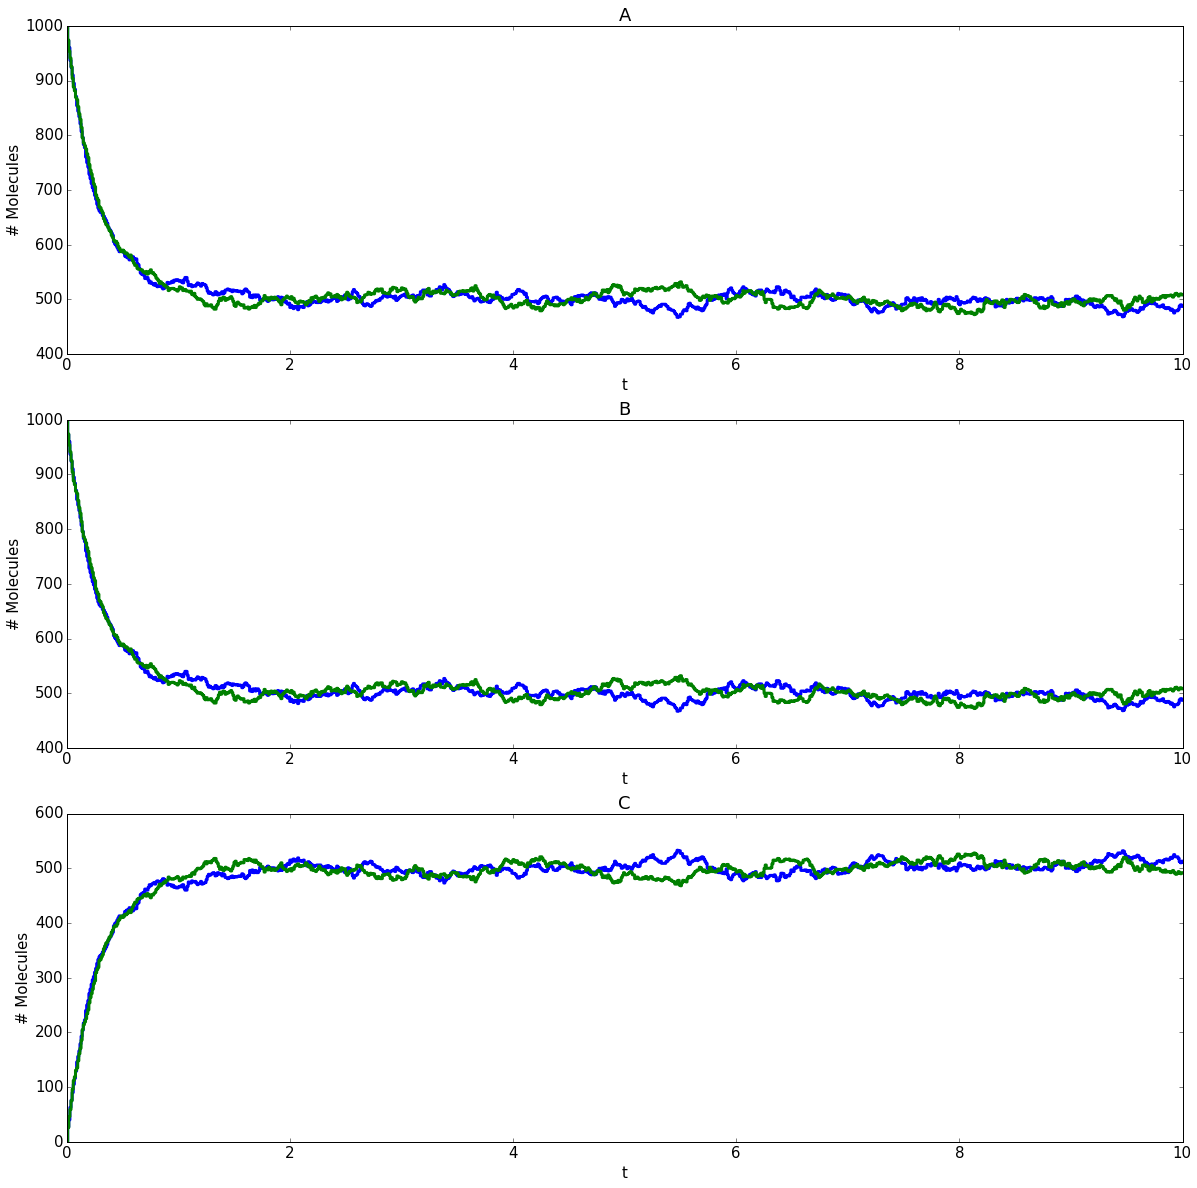

In [8]:
# Plot the time series for a single replicate.
dirname="data/1"
filename="%s/second_order_reversible.lm"%dirname
fp = h5py.File(filename, "r")
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,20)})
for replicate in (1,2):
    counts=np.array(fp["/Simulations/%07d/SpeciesCounts"%replicate], dtype=double)
    times=np.array(fp["/Simulations/%07d/SpeciesCountTimes"%replicate], dtype=double)
    plt.subplot(3,1,1)
    step(times,counts[:,0], **stepStyles)
    xlabel('t'); ylabel('# Molecules'); title("A")
    plt.subplot(3,1,2)
    step(times,counts[:,1], **stepStyles)
    xlabel('t'); ylabel('# Molecules'); title("B")
    plt.subplot(3,1,3)
    step(times,counts[:,2], **stepStyles)
    xlabel('t'); ylabel('# Molecules'); title("C")
pass

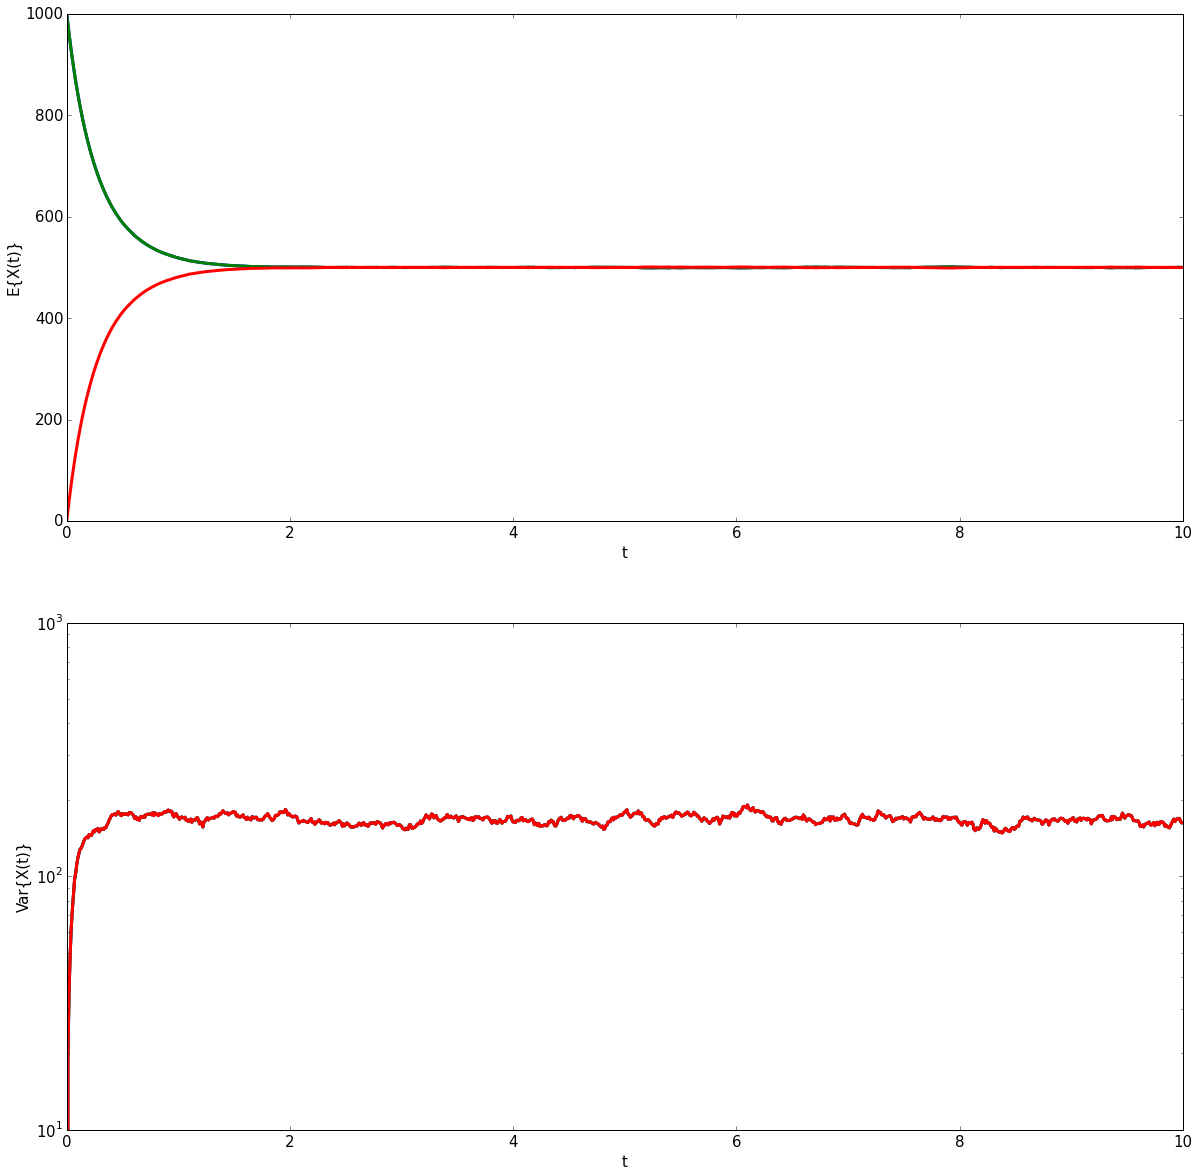

In [13]:
# Plot the mean and variance.
dirname="data/1"
filename="%s/second_order_reversible.lm"%dirname
fp = h5py.File(filename, "r")
replicates=fp["/Simulations"].keys()
k=0
mSim=None
vSim=None
times=None
for replicate in replicates:
    if times is None:
        times = np.array(fp["/Simulations/%s/SpeciesCountTimes"%replicate], dtype=double)
    counts = np.array(fp["/Simulations/%s/SpeciesCounts"%replicate], dtype=double)
    if mSim is None:
        k += 1
        mSim = counts
        vSim = np.zeros(counts.shape, dtype=double)
    else:
        k += 1
        mSim = mSim + (counts-mSim)/k
        vSim = vSim + (counts-mSim)*(counts-mSim)
vSim /= float((k-1))

matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,20)})
ax=plt.subplot(2,1,1)
plt.plot(times,mSim[:,0], **plotStyles)
plt.plot(times,mSim[:,1], **plotStyles)
plt.plot(times,mSim[:,2], **plotStyles)
ax.set_yscale('linear'); xlabel('t'); ylabel('E{X(t)}')

ax=plt.subplot(2,1,2)
plt.plot(times,vSim[:,0], **plotStyles)
plt.plot(times,vSim[:,1], **plotStyles)
plt.plot(times,vSim[:,2], **plotStyles)
ax.set_yscale('log'); xlabel('t'); ylabel('Var{X(t)}')
pass